In [1]:
import scanpy as sc
import spaflow
import argparse
from pathlib import Path
import os
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

parser = argparse.ArgumentParser()
parser.add_argument(
    '--dataset_name', 
    type=str, 
    default='mRCC_Visium', 
    help='Dataset sample name')
parser.add_argument(
    '--sample_name', 
    type=str, 
    default='RCC_W10_MET_A', 
    help='Dataset sample name')
parser.add_argument(
    '--time_steps', 
    type=int, 
    default=500, 
    help='Time steps')
parser.add_argument(
    '--grd_update_mode',
    type=str,
    default='full',
    help='GRD update function to use',
    choices=[
        'full',
        "no_diffusion",
        "no_binding",
        "no_unbinding",
        "no_production",
        "no_degradation",
    ])

args = parser.parse_args([])

print(args)

/users/PCON0022/huchen/spaflow/.venv/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/users/PCON0022/huchen/spaflow/.venv/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Namespace(dataset_name='mRCC_Visium', sample_name='RCC_W10_MET_A', time_steps=500, grd_update_mode='full')


/users/PCON0022/huchen/spaflow/.venv/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Fig. 2f

In [2]:
data_dir = f"/fs/ess/PAS1475/huchen/Diffusion/{args.dataset_name}/datasets/{args.sample_name}.h5ad"
adata = sc.read_h5ad(data_dir)
print(data_dir)

/fs/ess/PAS1475/huchen/Diffusion/mRCC_Visium/datasets/RCC_W10_MET_A.h5ad


In [3]:
res_dir = Path(
    f"/fs/ess/PAS1475/huchen/spaflow/{args.dataset_name}/{args.sample_name}"
)
os.makedirs(res_dir, exist_ok=True)
print(res_dir)

/fs/ess/PAS1475/huchen/spaflow/mRCC_Visium/RCC_W10_MET_A


In [4]:
df_ligrec = spaflow.filter_lr_database(adata)
df_ligrec.head()

,ligand,receptor,pathway,integrated_pathway,signaling type,complex
0,TGFB1,TGFBR1_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB1-TGFBR1_TGFBR2
2,TGFB3,TGFBR1_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB3-TGFBR1_TGFBR2
4,TGFB1,ACVR1B_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB1-ACVR1B_TGFBR2
6,TGFB3,ACVR1B_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB3-ACVR1B_TGFBR2
8,GDF15,TGFBR2,GDF,ACTIVIN_GDF_TGFb,Secreted Signaling,GDF15-TGFBR2


In [5]:
model_list = ["full", "no_diffusion", "no_unbinding", "no_production", "no_degradation"]
selected_coords = pd.read_csv(res_dir / "RCC_W10_MET_A_selected_coords.csv", index_col=0)

In [6]:
for model in model_list:
    spaflow_adata = spaflow.run_spaflow(adata, df_ligrec, model=model)
    spaflow_adata.write(res_dir / f"spaflow_adata_{model}.h5ad")

In [7]:
spaflow_adata_dict = {}
for model in ['full', 'no_diffusion', 'no_unbinding', 'no_production', 'no_degradation']:
    spaflow_adata_dict[model] = sc.read(res_dir / f"spaflow_adata_{model}.h5ad")

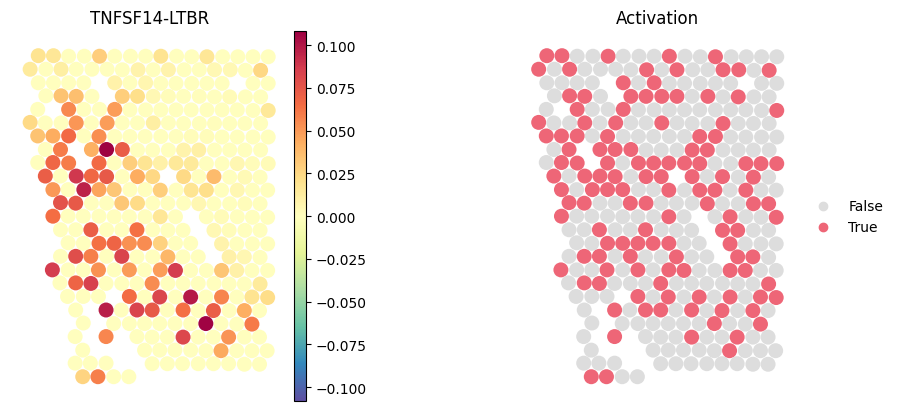

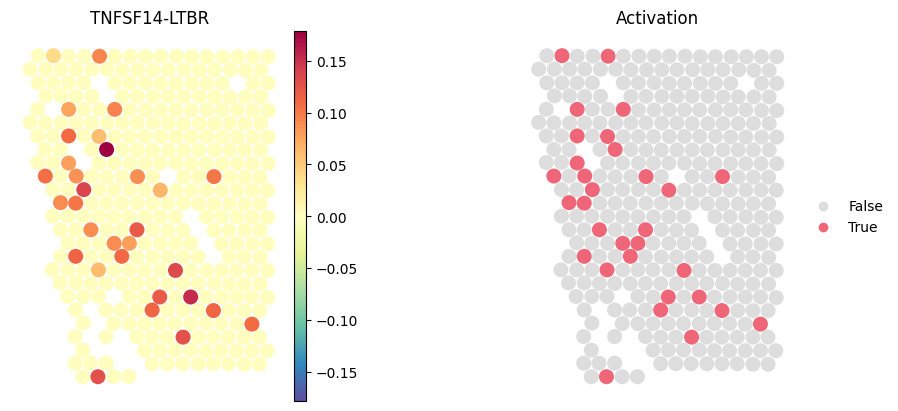

In [8]:
lr = 'TNFSF14-LTBR'
adata_full_sub = spaflow_adata_dict['full'][selected_coords.index].copy()
adata_full_sub.obs['Activation'] = adata_full_sub.obs[f'{lr}'] > 0
adata_full_sub.uns[f'Activation_colors'] = ["#DDDDDD", "#EE6677"]
sc.pl.spatial(adata_full_sub, color=[lr, 'Activation'], img_key=None, size=1.5, frameon=False, cmap='Spectral_r', vcenter=0)


adata_no_diffusion_sub = spaflow_adata_dict['no_diffusion'][selected_coords.index].copy()
adata_no_diffusion_sub.uns[f'Activation_colors'] = ["#DDDDDD", "#EE6677"]
adata_no_diffusion_sub.obs['Activation'] = adata_no_diffusion_sub.obs[f'{lr}'] > 0

sc.pl.spatial(adata_no_diffusion_sub, color=[lr, 'Activation'], img_key=None, size=1.5, frameon=False, cmap='Spectral_r', vcenter=0)

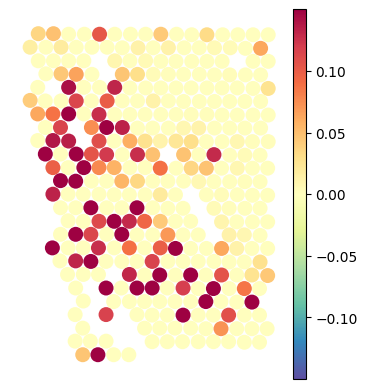

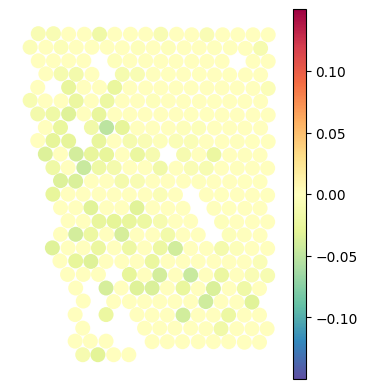

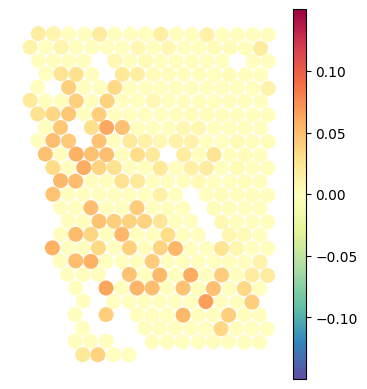

In [9]:
for model in ['no_unbinding', 'no_production', 'no_degradation']:
    adata1 = spaflow_adata_dict[model][selected_coords.index].copy()
    adata2 = spaflow_adata_dict['full'][selected_coords.index].copy()

    for _, row in df_ligrec.iterrows():
        complex = row['complex']
        adata1.obs[complex] = adata1.obs[complex] - adata2.obs[complex]

    sc.pl.spatial(
        adata1, 
        color=lr, 
        size=1.5, 
        frameon=False, 
        cmap='Spectral_r', 
        img_key=None,
        title='',
        vcenter=0,
        vmin=-0.15,
        vmax=0.15,
    )